<a href="https://colab.research.google.com/github/shathakshari2610/abc/blob/main/Another_copy_of_stock_price_prediction_keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predict stock prices  with Long short-term memory (LSTM)

This simple example will show you how LSTM models predict time series data. Stock market data is a great choice for this because it's quite regular and widely available via the Internet.

## Install requirements
We install Tensorflow 2.0 with GPU support first

In [ ]:
!pip install tensorflow-gpu==2.0.0-alpha0

In [ ]:
!pip install pandas-datareader

In [ ]:
!apt install graphviz

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 34 not upgraded.


In [ ]:
!pip install pydot pydot-ng

## Introduction

LSTMs are very powerful in sequence prediction problems. They can store past information.

## Loading the dataset
I use pandas-datareader to get the historical stock prices from Yahoo! finance. For this example, I get only the historical data till the end of *training_end_data*.  

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pandas_datareader import data
import yfinance as yf


In [ ]:
tickers = 'INFY.NS'

start_date = '2000-12-01'
end_date = '2018-12-31'

stock_data = yf.download(tickers, start_date, end_date)

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [ ]:
stock_data.head(10)

Price,Close,High,Low,Open,Volume
Ticker,INFY.NS,INFY.NS,INFY.NS,INFY.NS,INFY.NS
Date,,,,,
2000-12-01,74.489021,74.964782,72.063733,73.075548,54182464
2000-12-04,73.406212,74.802823,73.177786,74.710840,29766208
2000-12-05,73.397507,73.974957,72.373425,73.433278,43453632
2000-12-06,74.655632,77.674725,74.414431,77.674725,41569856
2000-12-07,74.473198,74.956110,73.893702,74.199803,23706944
2000-12-08,75.546341,75.821782,74.213093,74.213093,39107712
2000-12-11,76.343536,76.611821,75.242293,75.579564,39128768
2000-12-12,76.177444,77.470320,75.783961,76.448284,34921984


In [ ]:
stock_data.describe()

Price,Close,High,Low,Open,Volume
Ticker,INFY.NS,INFY.NS,INFY.NS,INFY.NS,INFY.NS
count,4518.000000,4518.000000,4518.000000,4518.000000,4.518000e+03
mean,219.794342,222.441332,217.156118,219.878709,1.696202e+07
std,149.083121,150.531118,147.705260,149.172966,1.721583e+07
min,22.326429,23.749804,21.589480,22.200374,0.000000e+00
25%,90.255009,91.102348,89.033145,89.992210,6.737021e+06
50%,201.278229,204.160933,198.487711,201.599875,1.045790e+07
75%,331.173447,335.485449,326.583680,329.599552,2.027118e+07
max,629.838745,636.798056,621.065768,627.940744,2.766150e+08


In [ ]:
stock_data_len = stock_data['Close'].count()
print(stock_data_len)

Ticker
INFY.NS    4518
dtype: int64


I'm only interested in *close* prices

In [ ]:
close_prices = stock_data.iloc[:, 1:2].values
print(close_prices)

[[ 74.71448274]
 [ 74.55305802]
 [ 73.72798056]
 ...
 [551.7220108 ]
 [565.57903333]
 [565.7922777 ]]


Of course, some of the weekdays might be public holidays in which case no price will be available. For this reason, we will fill the missing prices with the latest available prices

In [ ]:
all_bussinessdays = pd.date_range(start=start_date, end=end_date, freq='B')
print(all_bussinessdays)

DatetimeIndex(['2000-12-01', '2000-12-04', '2000-12-05', '2000-12-06',
               '2000-12-07', '2000-12-08', '2000-12-11', '2000-12-12',
               '2000-12-13', '2000-12-14',
               ...
               '2018-12-18', '2018-12-19', '2018-12-20', '2018-12-21',
               '2018-12-24', '2018-12-25', '2018-12-26', '2018-12-27',
               '2018-12-28', '2018-12-31'],
              dtype='datetime64[ns]', length=4717, freq='B')


In [ ]:
close_prices = stock_data.reindex(all_bussinessdays)
close_prices = stock_data.fillna(method='ffill')

<ipython-input-12-218da55dd8bc>:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  close_prices = stock_data.fillna(method='ffill')


In [ ]:
close_prices.head(10)

Price,Close,High,Low,Open,Volume
Ticker,INFY.NS,INFY.NS,INFY.NS,INFY.NS,INFY.NS
Date,,,,,
2000-12-01,74.240311,74.714483,71.823120,72.831557,54182464
2000-12-04,73.161110,74.553058,72.933447,74.461382,29766208
2000-12-05,73.152458,73.727981,72.131795,73.188110,43453632
2000-12-06,74.406349,77.415361,74.165953,77.415361,41569856
2000-12-07,74.224533,74.705833,73.646972,73.952051,23706944
2000-12-08,75.294106,75.568627,73.965309,73.965309,39107712
2000-12-11,76.088623,76.356012,74.991056,75.327202,39128768
2000-12-12,75.923103,77.211662,75.530933,76.193039,34921984


The dataset is now complete and free of missing values. Let's have a look to the data frame summary:

## Feature scaling

In [ ]:
training_set = close_prices.iloc[:, 1:2].values

In [ ]:
print(training_set)

[[ 74.71448274]
 [ 74.55305802]
 [ 73.72798056]
 ...
 [551.7220108 ]
 [565.57903333]
 [565.7922777 ]]


In [ ]:
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler(feature_range = (0, 1))
training_set_scaled = sc.fit_transform(training_set)
print(training_set_scaled.shape)

(4518, 1)


LSTMs expect the data in a specific format, usually a 3D tensor. I start by creating data with 60 days and converting it into an array using NumPy. Next, I convert the data into a 3D dimension array with feature_set samples, 60 days and one feature at each step.

In [ ]:
features = []
labels = []
for i in range(60,len(stock_data)):
    features.append(training_set_scaled[i-60:i, 0])
    labels.append(training_set_scaled[i, 0])

features = np.array(features)
labels = np.array(labels)

features = np.reshape(features, (features.shape[0], features.shape[1], 1))

In [ ]:
print(labels)

[0.05826202 0.05761401 0.05761402 ... 0.86122455 0.88382803 0.88417587]


In [ ]:
print(features)

[[[0.08313323]
  [0.08286991]
  [0.08152405]
  ...
  [0.06652003]
  [0.0642769 ]
  [0.05912605]]

 [[0.08286991]
  [0.08152405]
  [0.08753888]
  ...
  [0.0642769 ]
  [0.05912605]
  [0.05826202]]

 [[0.08152405]
  [0.08753888]
  [0.08311912]
  ...
  [0.05912605]
  [0.05826202]
  [0.05761401]]

 ...

 [[0.96828318]
  [0.96683834]
  [0.97199823]
  ...
  [0.89537321]
  [0.87861197]
  [0.87763832]]

 [[0.96683834]
  [0.97199823]
  [1.        ]
  ...
  [0.87861197]
  [0.87763832]
  [0.86122455]]

 [[0.97199823]
  [1.        ]
  [0.99594092]
  ...
  [0.87763832]
  [0.86122455]
  [0.88382803]]]


Feature tensor with three dimension: features[0] contains the ..., features[1] contains the last 60 days of values and features [2] contains the  ...

In [ ]:
print(features.shape)

(4458, 60, 1)


## Create the LSTM network
Let's create a sequenced LSTM network with 50 units. Also the net includes some dropout layers with 0.2 which means that 20% of the neurons will be dropped.

In [ ]:
import tensorflow as tf

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(units = 50, return_sequences = True, input_shape = (features.shape[1], 1)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.LSTM(units = 50, return_sequences = True),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.LSTM(units = 50, return_sequences = True),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.LSTM(units = 50),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(units = 1)
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 60, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,051 (277.54 KB)

 Trainable params: 71,051 (277.54 KB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
#tf.keras.utils.plot_model(model, to_file='my_model.png')


In [ ]:
# Run tensorboard with the logdir
#import os
#LOG_BASE_DIR = './log'
#os.makedirs(LOG_BASE_DIR, exist_ok=True)

In [ ]:
#!ls -l log

## Load the Colab TensorBoard extention and start TensorBoard inline

In [ ]:
#%load_ext tensorboard.notebook
#%tensorboard --logdir {LOG_BASE_DIR}

## Define a TensorBoard callback

In [ ]:
#import datetime
#logdir = os.path.join(LOG_BASE_DIR, datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))

In [ ]:
#from tensorflow.keras.callbacks import TensorBoard

#tbCallBack = TensorBoard(logdir,histogram_freq=1)

The model will be compiled and optimize by the adam optimizer and set the loss function as mean_squarred_error

In [ ]:
model.compile(optimizer = 'adam', loss = 'mean_squared_error')

In [ ]:
#import os
#print(os.environ)

In [ ]:
#tf.test.gpu_device_name()

In [ ]:
#from tensorflow.python.client import device_lib
#device_lib.list_local_devices()

In [ ]:
from time import time
start = time()
history = model.fit(features, labels, epochs = 20, batch_size = 32, verbose = 1)
end = time()

Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 0.0246
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0020
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0020
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0018
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0015
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0017
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0014
Epoch 8/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0016
Epoch 9/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0012
Epoch 10/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0013
Epoch 11/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0013
Epoch 12/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0012
Epoch 13/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0012
Epoch 14/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 9.8081e-04
Epoch 15/20
140/140 ━━━━━━━━━━━━━━━━━━━

In [ ]:
print('Total training time {} seconds'.format(end - start))

Total training time 47.04077744483948 seconds


In [ ]:
#  [samples, days, features]
print(features.shape)

(4458, 60, 1)


In [ ]:
testing_start_date = '2019-01-01'
testing_end_date = '2019-04-10'

test_stock_data = yf.download(tickers, testing_start_date, testing_end_date)

[*********************100%***********************]  1 of 1 completed


In [ ]:
test_stock_data.tail()

Price,Close,High,Low,Open,Volume
Ticker,INFY.NS,INFY.NS,INFY.NS,INFY.NS,INFY.NS
Date,,,,,
2019-04-03,645.899475,650.358104,640.326202,648.214537,6897127
2019-04-04,641.269348,646.328133,638.868512,644.270341,7688525
2019-04-05,651.043945,652.458720,641.355036,643.841594,6276040
2019-04-08,657.860474,660.218396,647.699991,654.259272,4919911
2019-04-09,652.158569,662.790679,650.100777,660.218399,6730692


In [ ]:
test_stock_data_processed = test_stock_data.iloc[:, 1:2].values


In [ ]:
print(test_stock_data_processed.shape)

(67, 1)


In [ ]:
all_stock_data = pd.concat((stock_data['Close'], test_stock_data['Close']), axis = 0)

In [ ]:
inputs = all_stock_data[len(all_stock_data) - len(test_stock_data) - 60:].values
inputs = inputs.reshape(-1,1)
inputs = sc.transform(inputs)

In [ ]:
X_test = []
for i in range(60, len(inputs)):
    X_test.append(inputs[i-60:i, 0])

In [ ]:
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
predicted_stock_price = model.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 147ms/step


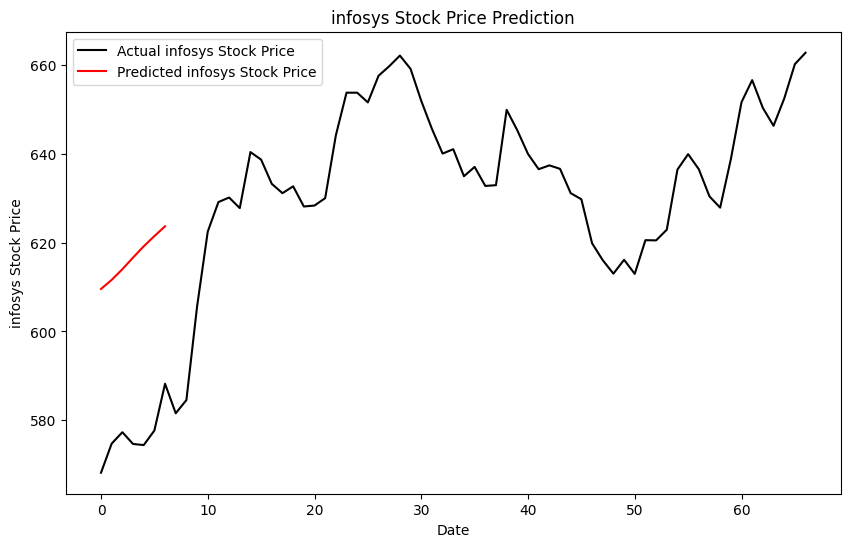

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(test_stock_data_processed, color='black', label='Actual infosys Stock Price')
plt.plot(predicted_stock_price , color='red', label='Predicted infosys Stock Price')
plt.title('infosys Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('infosys Stock Price')
plt.legend()
plt.show()

In [ ]:
#inputs = inputs.reshape(-1,1)
#inputs = sc.transform(inputs)


test_inputs = test_stock_data_processed.reshape(-1,1)
test_inputs = sc.transform(test_inputs)


print(test_inputs.shape)

(67, 1)


In [ ]:
test_features = []
for i in range(60, len(test_inputs)):
    test_features.append(test_inputs[i-60:i, 0])

test_features = np.array(test_features)

In [ ]:
test_features = np.reshape(test_features, (test_features.shape[0], test_features.shape[1], 1))
print(test_features.shape)

(7, 60, 1)


In [ ]:
predicted_stock_price = model.predict(test_features)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


In [ ]:
predicted_stock_price = sc.inverse_transform(predicted_stock_price)
print(predicted_stock_price.shape)

(7, 1)


In [ ]:
print(test_stock_data_processed.shape)

(67, 1)


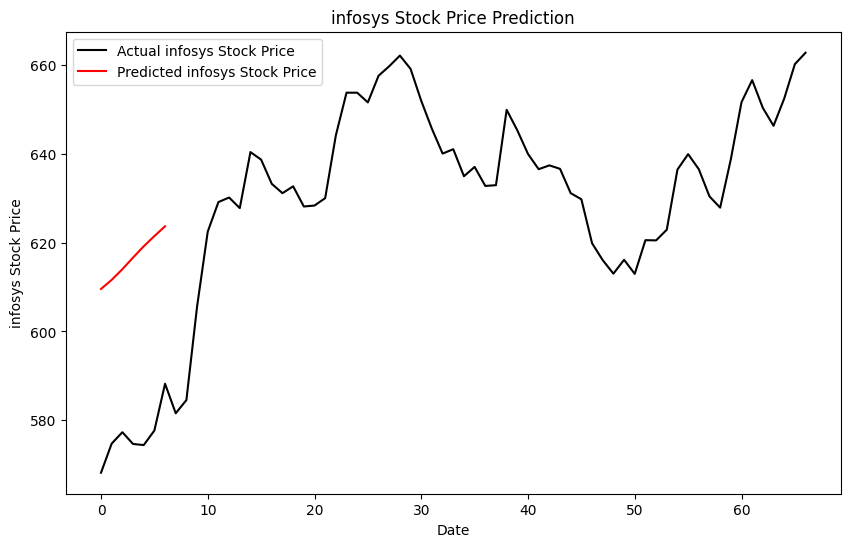

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(test_stock_data_processed, color='black', label='Actual infosys Stock Price')
plt.plot(predicted_stock_price , color='red', label='Predicted infosys Stock Price')
plt.title('infosys Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('infosys Stock Price')
plt.legend()
plt.show()

## Download the model and the weights

In [ ]:
from google.colab import files

In [ ]:
model_json = model.to_json()
with open("model.json", "w") as json_file:
  json_file.write(model_json)

In [ ]:
files.download("model.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
model.save('weights.h5')
files.download('weights.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Task
upload this dataset in here

Here is all the data you need:
"kaggle.csv"

## Data loading

### Subtask:
Load the dataset "kaggle.csv" into a pandas DataFrame.


**Reasoning**:
Load the dataset "kaggle.csv" into a pandas DataFrame and display the first 5 rows along with its shape.



In [ ]:
import pandas as pd

try:
    df = pd.read_csv('kaggle.csv')
    display(df.head())
    print(df.shape)
except FileNotFoundError:
    print("Error: 'kaggle.csv' not found. Please ensure the file exists in the current directory.")
    df = None # Assign None to df in case of error
except pd.errors.ParserError:
    print("Error: Could not parse 'kaggle.csv'. Please check the file format.")
    df = None
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    df = None

Error: Could not parse 'kaggle.csv'. Please check the file format.


**Reasoning**:
The previous attempt to load the data failed due to a parsing error.  I will try again but with the `encoding` parameter set to 'latin-1' as a common fix for parsing issues.  I will also check for the presence of the file again.



In [ ]:
import pandas as pd

try:
    df = pd.read_csv('kaggle.csv', encoding='latin-1')
    display(df.head())
    print(df.shape)
except FileNotFoundError:
    print("Error: 'kaggle.csv' not found. Please ensure the file exists in the current directory.")
    df = None
except pd.errors.ParserError:
    print("Error: Could not parse 'kaggle.csv' even with 'latin-1' encoding. Please check the file format.")
    df = None
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    df = None

Error: Could not parse 'kaggle.csv' even with 'latin-1' encoding. Please check the file format.


**Reasoning**:
The file continues to have parsing errors, even with different encodings. I will try one more encoding, 'ISO-8859-1', which is sometimes used for files with special characters. If this also fails, I will report the failure.



In [ ]:
import pandas as pd

try:
    df = pd.read_csv('kaggle.csv', encoding='ISO-8859-1')
    display(df.head())
    print(df.shape)
except FileNotFoundError:
    print("Error: 'kaggle.csv' not found. Please ensure the file exists in the current directory.")
    df = None
except pd.errors.ParserError:
    print("Error: Could not parse 'kaggle.csv'.  Tried multiple encodings, but still failed.  Please check the file format or provide additional details.")
    df = None
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    df = None

Error: Could not parse 'kaggle.csv'.  Tried multiple encodings, but still failed.  Please check the file format or provide additional details.
